In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf
import keras

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)


NumPy: 2.4.6
Pandas: 3.0.3
TensorFlow: 2.21.0
Keras: 3.14.1


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

cat = Table.read("lycan_small_cat_v2.fits")
spec = np.load("spectra_new_v2.npy")
cont = np.load("continum_v2.npy")

In [16]:
print(cat)
print("continuum shape:", cont.shape)
print("Columnas del catálogo:", cat.colnames)


     TARGETID             Z                  RA                 DEC            RSNR   PROGRAM SURVEY   FLUX_R  
----------------- ------------------ ------------------ ------------------- --------- ------- ------ ----------
39627917549896110 2.1932306549579392 3.2852438433390962   5.408003282780634  8.923307    dark   main   7.868383
39632961187873048  2.338182270630542 201.69553524689513  33.969364061938506 1.8647346    dark   main  1.1061417
39628359340131324  2.175913696417826  337.6124337155897   24.27043834050778 3.3887188    dark   main  2.4008994
39627781268573278 2.7136479150244046 153.87988269964285  -0.284166736018816 17.251913    dark   main  21.327236
39628053004948614 2.4043632422473817 236.15754039421245  10.921361157892035 1.5811208    dark   main  1.7523378
39627539492110579 2.8345350550604174  73.88571439778211 -10.240072402858951 1.7643958    dark   main  1.0831243
39627913682748959  2.574049589857051 132.19330451249238   5.190549468522186 2.7091944    dark   main  1.

In [17]:
Z = np.array(cat["Z"])
FLUX_R = np.array(cat["FLUX_R"])

X = np.vstack([Z, FLUX_R]).T
Y = np.array(cont)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (200000, 2)
Y shape: (200000, 699)


In [18]:
# Filas válidas: sin NaN ni infinitos en X ni en Y
mask = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)

print("Filas originales:", X.shape[0])
print("Filas válidas:", mask.sum())
print("Filas eliminadas:", X.shape[0] - mask.sum())

X = X[mask]
Y = Y[mask]

print("Nuevo X shape:", X.shape)
print("Nuevo Y shape:", Y.shape)

Filas originales: 200000
Filas válidas: 199997
Filas eliminadas: 3
Nuevo X shape: (199997, 2)
Nuevo Y shape: (199997, 699)


In [19]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)

num_puntos = Y.shape[1]

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(num_puntos, activation="linear")
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    X_train_scaled,
    Y_train,
    validation_data=(X_val_scaled, Y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 12.9227 - mae: 1.7253 - val_loss: 11.5652 - val_mae: 1.5981
Epoch 2/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - loss: 12.8529 - mae: 1.7276 - val_loss: 11.5221 - val_mae: 1.7080
Epoch 3/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 12.8448 - mae: 1.7287 - val_loss: 11.5256 - val_mae: 1.6476
Epoch 4/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 12.8450 - mae: 1.7289 - val_loss: 11.5184 - val_mae: 1.6811
Epoch 5/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 12.8418 - mae: 1.7290 - val_loss: 11.5283 - val_mae: 1.7301
Epoch 6/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - loss: 12.8402 - mae: 1.7283 - val_loss: 11.5462 - val_mae: 1.7579
Epoch 7/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 12.8410 - mae: 1.7290 - val_loss: 11.5387 - val_mae: 1.7516
Epoch 8/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 12.8429 - mae: 1.7291 - val_loss: 11.5210 - val_mae: 1.7073
Epoch 9/50
5000/

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


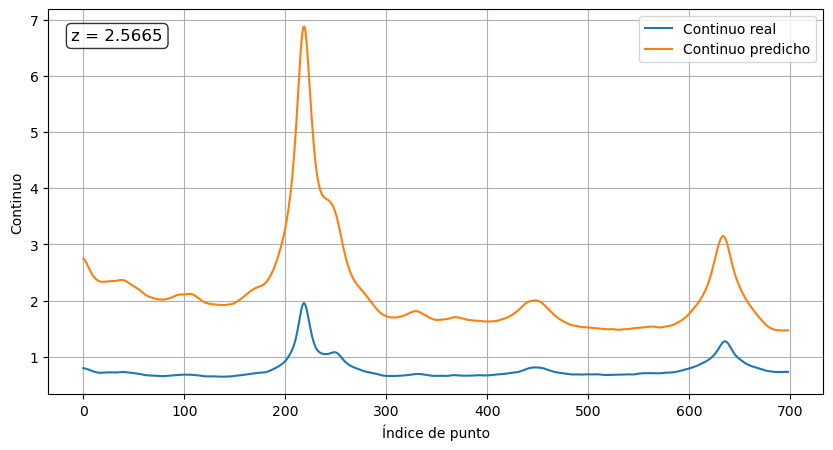

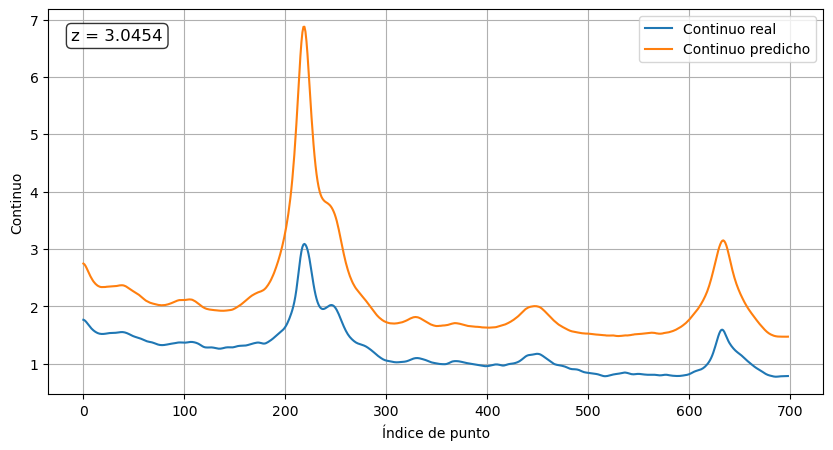

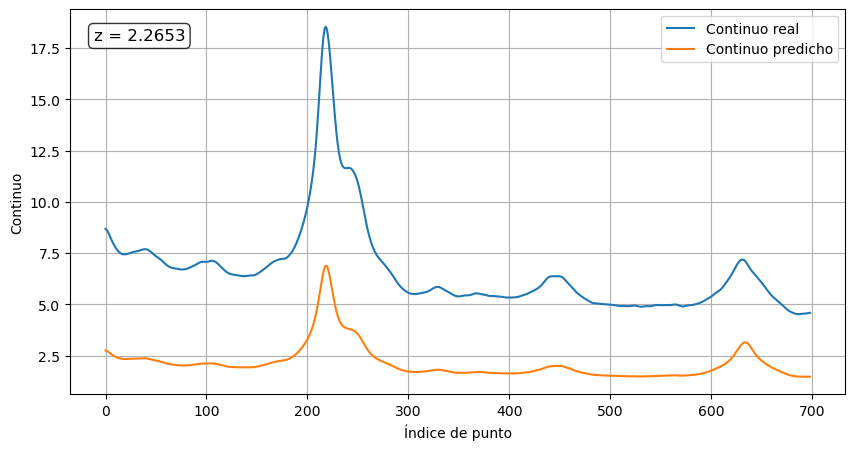

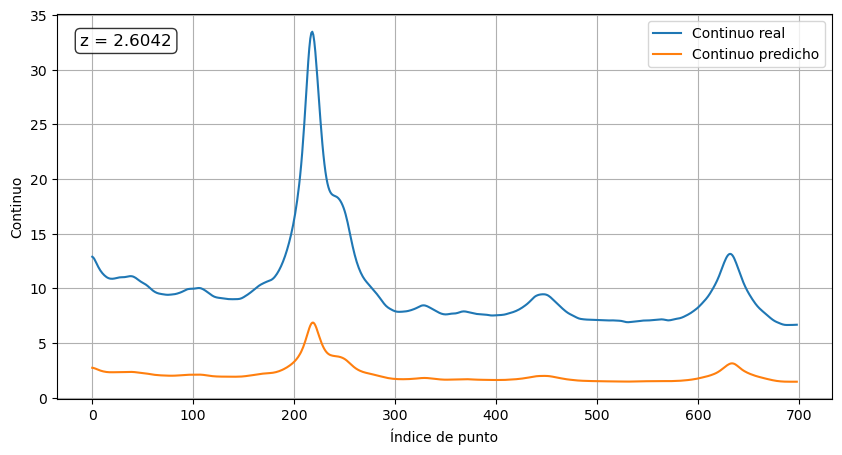

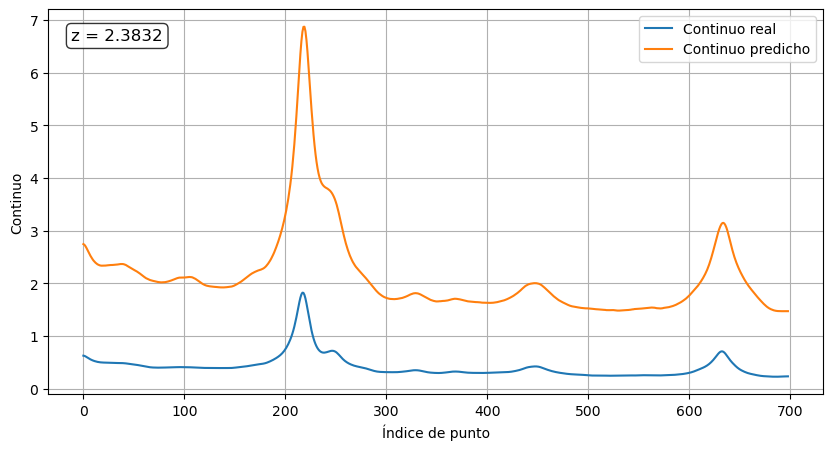

In [20]:
import matplotlib.pyplot as plt

Y_pred = model.predict(X_val_scaled)

indices = [0, 10, 50, 100, 500]

for i in indices:
    z = X_val[i][0]

    plt.figure(figsize=(10, 5))
    plt.plot(Y_val[i], label="Continuo real")
    plt.plot(Y_pred[i], label="Continuo predicho")

    plt.xlabel("Índice de punto")
    plt.ylabel("Continuo")

    # Cuadro con el redshift
    plt.text(
        0.03, 0.95,
        f"z = {z:.4f}",
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    plt.legend()
    plt.grid()
    plt.show()

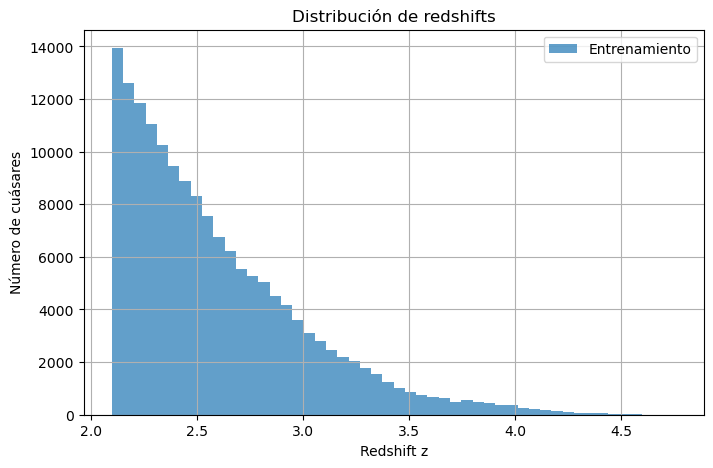

In [25]:
import numpy as np
import matplotlib.pyplot as plt

z_train = X_train[:, 0]
z_val = X_val[:, 0]

plt.figure(figsize=(8, 5))
plt.hist(z_train, bins=50, alpha=0.7, label="Entrenamiento")
plt.xlabel("Redshift z")
plt.ylabel("Número de cuásares")
plt.title("Distribución de redshifts")
plt.legend()
plt.grid()
plt.show()

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


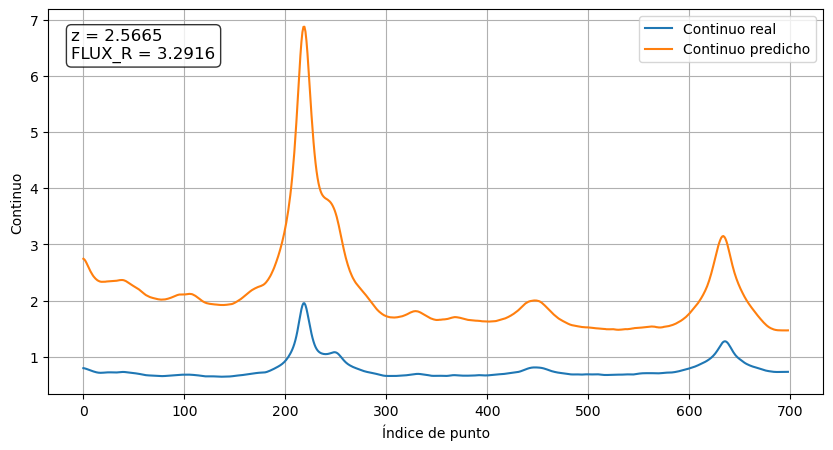

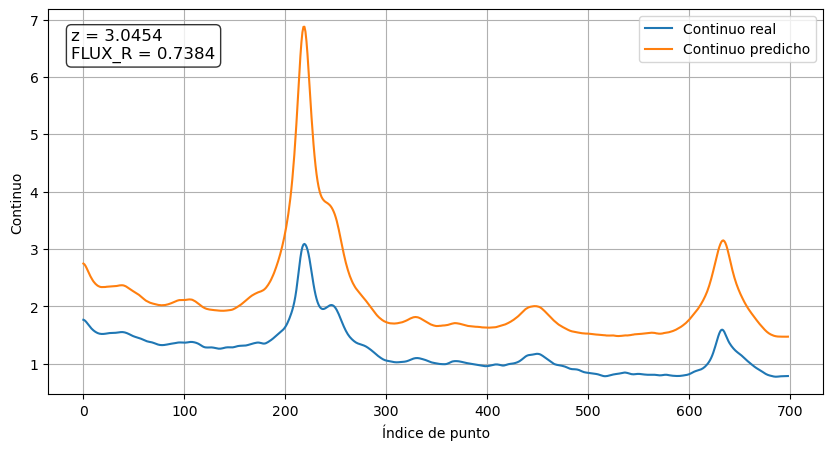

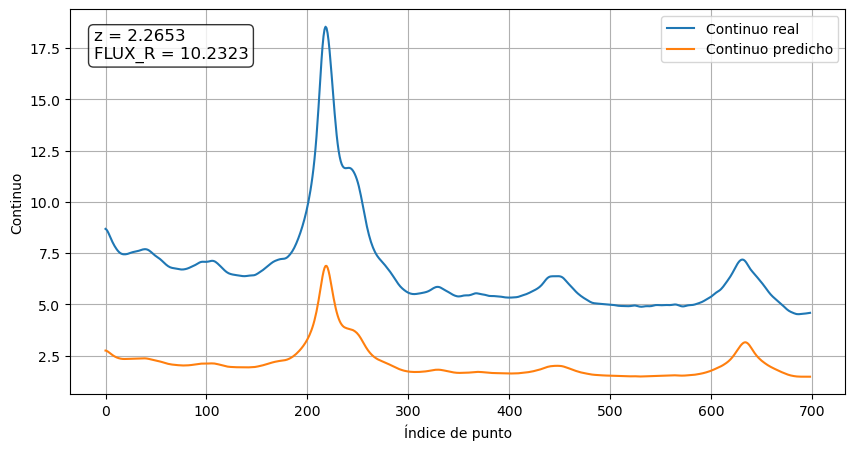

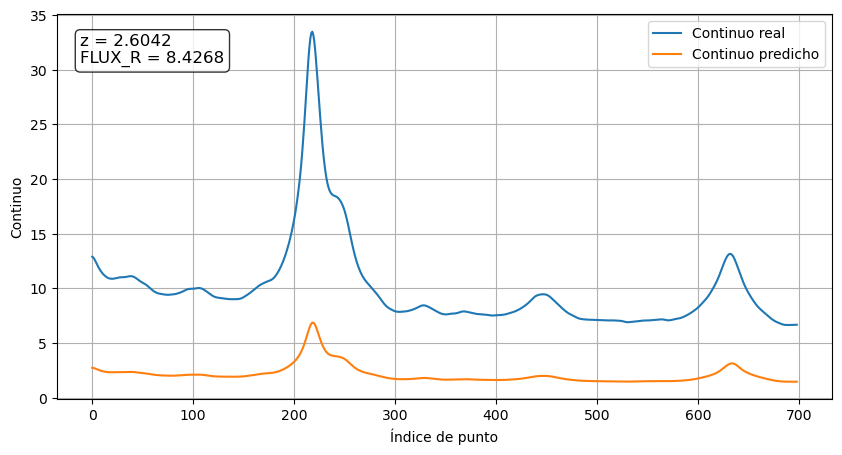

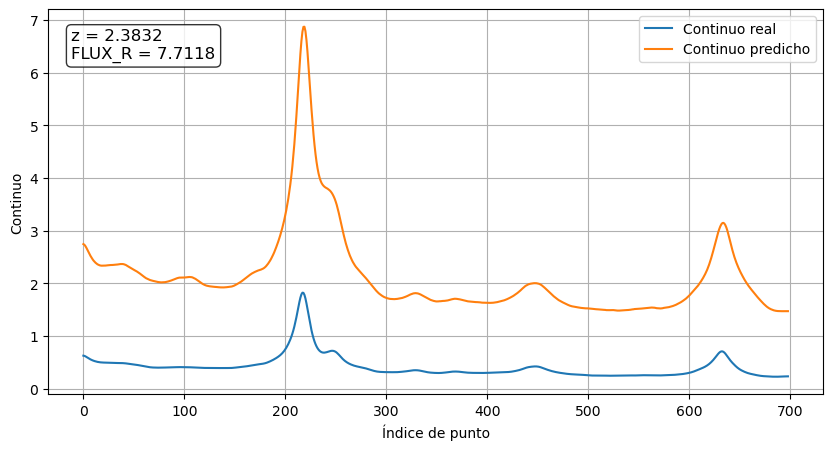

In [34]:
import matplotlib.pyplot as plt
import os

Y_pred = model.predict(X_val_scaled)

# Crear carpeta para guardar figuras
os.makedirs("figuras_continuo", exist_ok=True)

indices = [0, 10, 50, 100, 500]

for i in indices:
    z = X_val[i][0]
    flux_r = X_val[i, 1]

    plt.figure(figsize=(10, 5))
    plt.plot(Y_val[i], label="Continuo real")
    plt.plot(Y_pred[i], label="Continuo predicho")

    plt.xlabel("Índice de punto")
    plt.ylabel("Continuo")

    # Cuadro con el redshift
    plt.text(
        0.03, 0.95,
        f"z = {z:.4f}\nFLUX_R = {flux_r:.4f}",
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    plt.legend()
    plt.grid()

    # Guardar figura
    nombre_figura = f"figuras_continuo/continuo_predicho_indice_{i}_z_{z:.4f}.png"
    plt.savefig(nombre_figura, dpi=300, bbox_inches="tight")

    plt.show()

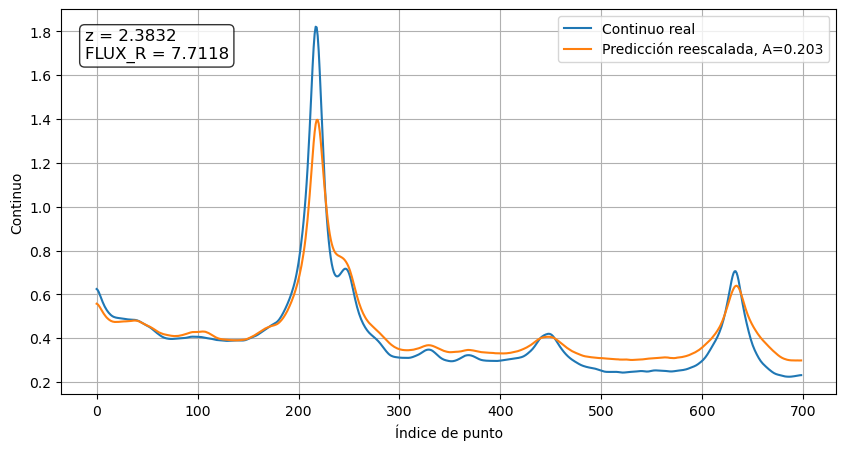

In [42]:
import numpy as np
import matplotlib.pyplot as plt

i = 500

y_real = Y_val[i]
y_pred = Y_pred[i]

z = X_val[i][0]
flux_r = X_val[i, 1]

# Factor multiplicativo óptimo
A = np.sum(y_real * y_pred) / np.sum(y_pred**2)

y_pred_rescaled = A * y_pred

plt.figure(figsize=(10, 5))
plt.plot(y_real, label="Continuo real")
#plt.plot(y_pred, label="Predicción original")
plt.plot(y_pred_rescaled, label=f"Predicción reescalada, A={A:.3f}")
plt.xlabel("Índice de punto")
plt.ylabel("Continuo")
plt.text(
        0.03, 0.95,
        f"z = {z:.4f}\nFLUX_R = {flux_r:.4f}",
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.legend()
plt.grid()
nombre_figura = f"figuras_continuo/continuo_predicho_reescalado_indice_{i}_z_{z:.4f}.png"
plt.savefig(nombre_figura, dpi=300, bbox_inches="tight")
plt.show()

In [24]:
tf.keras.utils.plot_model(model)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
